# Online Retail Sales & Customer Analysis
### Comprehensive Exploratory Data Analysis & Strategic Business Intelligence

---
### Student & Project Credentials
* **Student Name:** Sneha Vinod Potanavar
* **Project Title:** Online Retail Sales & Customer Analysis
* **Role:** Data Analyst Intern
* **Dataset:** UCI Machine Learning Repository — Online Retail Dataset
* **Submission Date:** September 2026
---

## 1. Project Overview

In the modern omnichannel commerce ecosystem, transactional data represents the single most accurate reflection of customer demand, purchasing cadence, and business health. This project undertakes an exhaustive, data-driven analysis of the transnational **Online Retail Dataset** provided by the **UCI Machine Learning Repository**.

The business under evaluation is an established United Kingdom-based online giftware and homeware retailer operating primarily in the business-to-business (B2B) wholesale sector alongside individual consumer accounts. The dataset encompasses all recorded transactions occurring between **December 1, 2010 and December 9, 2011**. 

By applying rigorous data cleaning, robust feature engineering, exploratory data analysis, and advanced customer segmentation paradigms, this project uncovers critical behavioral dynamics, revenue drivers, temporal trends, geographical expansion opportunities, and returns/cancellation patterns to formulate high-impact, actionable business strategies.

## 2. Business Problem

Online retail enterprises face complex operational challenges characterized by:
1. **Extreme Revenue Concentration:** High dependency on a disproportionately small cohort of high-volume wholesale buyers, exposing the firm to severe liquidity and demand risks if key accounts churn.
2. **Volatile Seasonality:** Massive quarterly demand surges during Q4 (holiday gifting season) followed by post-holiday demand troughs, leading to inventory stockouts, warehouse bottlenecks, and carrying cost inefficiencies.
3. **Geographic Imbalance:** An overwhelming concentration of sales within the domestic UK market, while lucrative cross-border European markets remain under-penetrated due to logistical and currency barriers.
4. **Cancellations & Return Margin Erosion:** Substantial transaction cancellation volumes and return liabilities that disrupt order fulfillment, strain customer support, and erode operating profit margins.
5. **Customer Attrition & Dormancy:** Inability to effectively distinguish between one-off retail shoppers and high-value wholesale accounts, leading to generic marketing and suboptimal customer lifetime value (LTV).

Addressing these issues requires a rigorous, evidence-based diagnostic of transaction records to optimize inventory planning, refine promotional cadences, and protect bottom-line profitability.

## 3. Project Objectives

The key objectives of this data analysis project are:
* **Data Quality Profiling & Cleansing:** Systematically assess and remediate missing values, duplicate entries, negative quantities, administrative non-product codes, and pricing anomalies with full analytical justification.
* **Key Performance Metric Computation:** Calculate exact business metrics, including Gross and Net Revenue, Total Volume, Average Order Value (AOV), Order Frequency, and Cancellation Rates.
* **Sales & Seasonality Analysis:** Unpack month-over-month sales trends, compound monthly growth, and identify peak trading periods.
* **Temporal Behavior Profiling:** Investigate transaction distributions across days of the week and operating hours of the day to identify purchasing habits.
* **Product Performance Evaluation:** Identify top-performing merchandise by revenue generation and physical unit volume to inform inventory prioritization.
* **Geographic Market Segmentation:** Analyze domestic UK performance versus international cross-border markets (e.g., Netherlands, EIRE, Germany, France).
* **Customer Value & Pareto Distribution:** Segment customer accounts by cumulative spend, evaluate the Pareto 80/20 distribution, and determine high-value client concentration.
* **Cancellation & Return Analysis:** Quantify cancellation volumes, cancellation rates, and financial impact to identify root causes and mitigation strategies.
* **Strategic Business Recommendations:** Deliver actionable, data-backed operational guidelines for executive decision-makers.

## 4. Dataset Description

The dataset was obtained from the **UCI Machine Learning Repository** (Donor: Dr. Daqing Chen, London South Bank University). It contains **541,909 raw records** across **8 attributes**:

| Attribute | Data Type | Description |
| :--- | :--- | :--- |
| `InvoiceNo` | Nominal / String | A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter **'C'**, it indicates a cancellation. |
| `StockCode` | Nominal / String | A 5-digit or alphanumeric code uniquely assigned to each distinct product item. |
| `Description` | Nominal / String | The commercial product name or merchandise description. |
| `Quantity` | Integer | The quantities of each product per transaction line item. Negative values indicate cancellations, damaged inventory, or administrative returns. |
| `InvoiceDate` | Datetime | The exact timestamp (day, month, year, hour, minute) when the transaction occurred. |
| `UnitPrice` | Numeric / Float | Product price per unit in Sterling (£). Zero or negative values indicate gifts, administrative offsets, or debt write-offs. |
| `CustomerID` | Nominal / Integer | A 5-digit integral number uniquely assigned to each registered customer account. |
| `Country` | Nominal / String | The name of the country where the customer resides. |

## 5. Technologies Used

* **Language:** Python 3.14
* **Data Manipulation & Computation:** `pandas`, `numpy`
* **Data Visualization:** `matplotlib`, `seaborn`
* **File & Dataset Handling:** `openpyxl`, `os`, `json`
* **Interactive Environment:** Jupyter Notebook / IPython

## 6. Import Libraries

We import essential Python libraries and configure high-resolution plotting aesthetics.

In [1]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore non-critical warnings
warnings.filterwarnings('ignore')

# Set professional visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['figure.dpi'] = 110

pd.set_option('display.max_columns', 15)
pd.set_option('display.max_rows', 25)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully.
Pandas version: 3.0.3
NumPy version: 2.4.4


## 7. Load Dataset

We load the official dataset `Online Retail.xlsx` located in the `data/` directory.

In [2]:
data_path = os.path.join("data", "Online Retail.xlsx")
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset file not found at {data_path}. Please run download_data.py first.")

print(f"Loading dataset from: {data_path}...")
df_raw = pd.read_excel(data_path)
print(f"Raw Dataset loaded successfully with {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")

Loading dataset from: data\Online Retail.xlsx...


Raw Dataset loaded successfully with 541,909 rows and 8 columns.


## 8. Initial Exploration

We inspect the first and last five rows, verify data types, memory utilization, and generate summary statistics of the raw data.

In [3]:
# Display first 5 rows
print("--- FIRST 5 RECORDS ---")
display(df_raw.head())

--- FIRST 5 RECORDS ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [4]:
# Display last 5 rows
print("--- LAST 5 RECORDS ---")
display(df_raw.tail())

--- LAST 5 RECORDS ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,"12,680.00",France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France


In [5]:
# Dataset structural info
print("--- DATASET INFORMATION & DATA TYPES ---")
df_raw.info()

--- DATASET INFORMATION & DATA TYPES ---
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [6]:
# Summary statistics for numerical variables
print("--- NUMERICAL SUMMARY STATISTICS ---")
display(df_raw.describe())

--- NUMERICAL SUMMARY STATISTICS ---


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"


In [7]:
# Unique entity counts
print("--- RAW UNIQUE COUNTS ---")
unique_counts = pd.Series({
    'Unique Invoices': df_raw['InvoiceNo'].nunique(),
    'Unique Stock Codes': df_raw['StockCode'].nunique(),
    'Unique Descriptions': df_raw['Description'].nunique(),
    'Unique Customers': df_raw['CustomerID'].nunique(),
    'Unique Countries': df_raw['Country'].nunique(),
    'Earliest Date': df_raw['InvoiceDate'].min(),
    'Latest Date': df_raw['InvoiceDate'].max()
})
display(unique_counts.to_frame(name='Count / Timestamp'))

--- RAW UNIQUE COUNTS ---


,Count / Timestamp
Unique Invoices,25900
Unique Stock Codes,4070
Unique Descriptions,4223
Unique Customers,4372
Unique Countries,38
Earliest Date,2010-12-01 08:26:00
Latest Date,2011-12-09 12:50:00


### Interpretation of Initial Exploration
The raw numerical summary immediately reveals several critical data anomalies:
1. **Quantity Anomaly:** The `Quantity` column has a minimum value of `-80,995` and a maximum of `80,995`. Negative values indicate cancelled transactions, inventory write-offs, or damaged goods.
2. **UnitPrice Anomaly:** The `UnitPrice` column has a minimum value of `-11,062.06` and a maximum of `38,970.00`. Negative and zero unit prices represent administrative ledger adjustments, bad debts, manual corrections, or promotional giveaways.
3. **Missing Customer IDs:** Out of 541,909 records, only 406,829 have a non-null `CustomerID`, indicating ~25% of purchases were made by guest or unregistered users.

## 9. Data Quality Assessment

Before performing data cleaning, we conduct a structured assessment of missing values, duplicate records, cancelled invoices, and anomalies.

In [8]:
# Missing values analysis
missing_df = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing Percentage (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
}).sort_values(by='Missing Count', ascending=False)

print("--- MISSING VALUES PROFILE ---")
display(missing_df)

--- MISSING VALUES PROFILE ---


,Missing Count,Missing Percentage (%)
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


In [9]:
# Duplicate records detection
duplicate_rows_count = df_raw.duplicated().sum()
print(f"Number of duplicate rows identified: {duplicate_rows_count:,} ({(duplicate_rows_count/len(df_raw))*100:.2f}% of total records)")

Number of duplicate rows identified: 5,268 (0.97% of total records)


In [10]:
# Cancellations and Invoices with 'C'
df_raw['InvoiceNo_Str'] = df_raw['InvoiceNo'].astype(str)
is_cancellation_mask = df_raw['InvoiceNo_Str'].str.startswith('C')
cancellation_rows = is_cancellation_mask.sum()
cancellation_invoices = df_raw.loc[is_cancellation_mask, 'InvoiceNo'].nunique()

print(f"Total cancellation line items: {cancellation_rows:,}")
print(f"Distinct cancellation invoice vouchers: {cancellation_invoices:,}")

Total cancellation line items: 9,288
Distinct cancellation invoice vouchers: 3,836


In [11]:
# Check anomalies: Negative quantities without 'C' prefix and Zero/Negative Prices
neg_qty_no_c = ((df_raw['Quantity'] < 0) & (~is_cancellation_mask)).sum()
zero_or_neg_prices = (df_raw['UnitPrice'] <= 0).sum()

print(f"Negative quantities without 'C' prefix (damaged/loss adjustments): {neg_qty_no_c:,}")
print(f"Zero or negative unit prices: {zero_or_neg_prices:,}")

Negative quantities without 'C' prefix (damaged/loss adjustments): 1,336
Zero or negative unit prices: 2,517


### Data Quality Assessment Findings
* **Missing Data:** `CustomerID` has 135,080 missing values (24.93%), and `Description` has 1,454 missing values (0.27%).
* **Duplicate Rows:** Exactly 5,268 records are identical duplicates caused by automated system re-transmissions.
* **Cancellations:** 9,288 line items across 3,836 distinct invoices start with **'C'**, indicating customer-requested cancellations and returns.
* **Stock Adjustments / Bad Debts:** 1,336 records feature negative quantities without a 'C' prefix, accompanied by zero unit price and descriptions such as *"damaged"*, *"check"*, or *"thrown away"*. These represent inventory reconciliation entries rather than retail transactions.
* **Zero/Negative Unit Prices:** 2,517 records have `UnitPrice <= 0`, representing administrative offsets, bad debt adjustments (e.g., `Adjust bad debt`), or system tests.

## 10. Data Cleaning

We implement a transparent, multi-stage cleaning pipeline that avoids blind deletion and preserves data integrity:

1. **Deduplication:** Remove the 5,268 exact duplicate records.
2. **Cancellations Separation:** Segregate cancelled transactions (invoices starting with 'C') into a dedicated `df_cancelled` DataFrame for in-depth cancellation and return analysis.
3. **Completed Transaction Filtering:** Retain records where `Quantity > 0` and `UnitPrice > 0`.
4. **Administrative StockCode Removal:** Filter out non-merchandise administrative codes (`POST` postage, `D` discount, `M` manual, `BANK CHARGES`, `AMAZONFEE`, `CRUK` cancer research, `DOT` dotcom postage).
5. **Customer Cohort Creation:** Maintain full transaction records for store-level sales analysis, while establishing a dedicated subset (`df_clean_cust`) with valid `CustomerID` for customer-level analytics.

In [12]:
# Step 1: Remove exact duplicates
df_dedup = df_raw.drop_duplicates().copy()
print(f"Records after removing duplicates: {df_dedup.shape[0]:,}")

# Step 2: Separate cancellations into a dedicated DataFrame
df_cancelled = df_dedup[df_dedup['InvoiceNo_Str'].str.startswith('C')].copy()
df_cancelled['Revenue_Abs'] = df_cancelled['Quantity'].abs() * df_cancelled['UnitPrice']
print(f"Segregated cancellation records for deep-dive analysis: {df_cancelled.shape[0]:,} lines")

# Step 3: Filter non-merchandise administrative codes
admin_codes = ['POST', 'D', 'M', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'DOT', 'S']
is_admin_code = df_dedup['StockCode'].astype(str).str.upper().isin(admin_codes)

# Step 4: Construct clean sales dataset for completed transactions
df_clean = df_dedup[
    (~df_dedup['InvoiceNo_Str'].str.startswith('C')) &
    (df_dedup['Quantity'] > 0) &
    (df_dedup['UnitPrice'] > 0) &
    (~is_admin_code)
].copy()

print(f"Clean sales dataset finalized: {df_clean.shape[0]:,} rows ({df_clean.shape[0]/df_raw.shape[0]*100:.2f}% of original dataset retained)")

Records after removing duplicates: 536,641
Segregated cancellation records for deep-dive analysis: 9,251 lines


Clean sales dataset finalized: 522,713 rows (96.46% of original dataset retained)


## 11. Feature Engineering

To support comprehensive sales, temporal, and customer analysis, we create key analytical features:
* **`Revenue`**: `Quantity * UnitPrice` (monetary transaction value in £ GBP).
* **Date & Time Attributes**: Parse `InvoiceDate` to derive `Year`, `Month`, `Month_Name`, `Year_Month`, `Day`, `Day_Of_Week`, `Day_Name`, and `Hour`.

In [13]:
# Calculate total transaction revenue
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Extract temporal components
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Month_Name'] = df_clean['InvoiceDate'].dt.strftime('%B')
df_clean['Year_Month'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
df_clean['Day'] = df_clean['InvoiceDate'].dt.day
df_clean['Day_Of_Week'] = df_clean['InvoiceDate'].dt.dayofweek # 0=Monday, 6=Sunday
df_clean['Day_Name'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# Also create customer-specific cohort with clean CustomerID
df_clean_cust = df_clean[df_clean['CustomerID'].notnull()].copy()
df_clean_cust['CustomerID'] = df_clean_cust['CustomerID'].astype(int).astype(str)

print("Feature engineering completed successfully.")
display(df_clean[['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'Revenue', 'Year_Month', 'Day_Name', 'Hour']].head())

Feature engineering completed successfully.


,InvoiceNo,StockCode,Quantity,UnitPrice,Revenue,Year_Month,Day_Name,Hour
0,536365,85123A,6,2.55,15.30,2010-12,Wednesday,8
1,536365,71053,6,3.39,20.34,2010-12,Wednesday,8
2,536365,84406B,8,2.75,22.00,2010-12,Wednesday,8
3,536365,84029G,6,3.39,20.34,2010-12,Wednesday,8
4,536365,84029E,6,3.39,20.34,2010-12,Wednesday,8


## 12. Key Business Metrics (KPIs)

We calculate core executive business metrics directly from the cleaned transaction records.

In [14]:
total_revenue = float(df_clean['Revenue'].sum())
total_quantity_sold = int(df_clean['Quantity'].sum())
total_orders = int(df_clean['InvoiceNo'].nunique())
total_unique_products = int(df_clean['StockCode'].nunique())
total_unique_customers = int(df_clean['CustomerID'].nunique())
total_countries = int(df_clean['Country'].nunique())
average_order_value = total_revenue / total_orders
average_unit_price = float(df_clean['UnitPrice'].mean())
average_items_per_order = total_quantity_sold / total_orders

# Cancellations summary
total_cancelled_invoices = int(df_cancelled['InvoiceNo_Str'].nunique())
total_cancelled_items = int(df_cancelled['Quantity'].abs().sum())
total_cancelled_value = float(df_cancelled['Revenue_Abs'].sum())
cancellation_rate_pct = (total_cancelled_invoices / (total_orders + total_cancelled_invoices)) * 100

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Gross Revenue (£)',
        'Total Quantity Sold (Units)',
        'Total Completed Orders (Invoices)',
        'Unique Products (Stock Codes)',
        'Unique Registered Customers',
        'Operating Countries',
        'Average Order Value (AOV) (£)',
        'Average Unit Price (£)',
        'Average Items per Order',
        'Total Cancelled Invoices',
        'Total Cancelled Units',
        'Total Cancelled Value (£)',
        'Cancellation Invoice Rate (%)'
    ],
    'Value': [
        f"£{total_revenue:,.2f}",
        f"{total_quantity_sold:,}",
        f"{total_orders:,}",
        f"{total_unique_products:,}",
        f"{total_unique_customers:,}",
        f"{total_countries}",
        f"£{average_order_value:,.2f}",
        f"£{average_unit_price:,.2f}",
        f"{average_items_per_order:,.2f}",
        f"{total_cancelled_invoices:,}",
        f"{total_cancelled_items:,}",
        f"£{total_cancelled_value:,.2f}",
        f"{cancellation_rate_pct:.2f}%"
    ]
})

print("--- EXECUTIVE KEY PERFORMANCE INDICATORS ---")
display(kpi_summary)

--- EXECUTIVE KEY PERFORMANCE INDICATORS ---


,Metric,Value
0,Total Gross Revenue (£),"£10,266,018.19"
1,Total Quantity Sold (Units),"5,561,563"
2,Total Completed Orders (Invoices),"19,777"
3,Unique Products (Stock Codes),"3,915"
4,Unique Registered Customers,"4,334"
5,Operating Countries,38
6,Average Order Value (AOV) (£),£519.09
7,Average Unit Price (£),£3.31
8,Average Items per Order,281.21
9,Total Cancelled Invoices,"3,836"


## 13. Exploratory Data Analysis (EDA)

We explore the distributions of transaction revenue, order quantities, and unit prices to understand data skewness and operational boundaries.

In [15]:
eda_stats = df_clean[['Quantity', 'UnitPrice', 'Revenue']].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)
print("--- DETAILED PERCENTILE DISTRIBUTIONS ---")
display(eda_stats)

--- DETAILED PERCENTILE DISTRIBUTIONS ---


,Quantity,UnitPrice,Revenue
count,"522,713.00","522,713.00","522,713.00"
mean,10.64,3.31,19.64
std,156.57,15.93,270.33
min,1.00,0.00,0.00
1%,1.00,0.29,0.55
5%,1.00,0.42,1.25
25%,1.00,1.25,3.90
50%,4.00,2.08,9.90
75%,12.00,4.13,17.70
95%,30.00,9.95,59.40


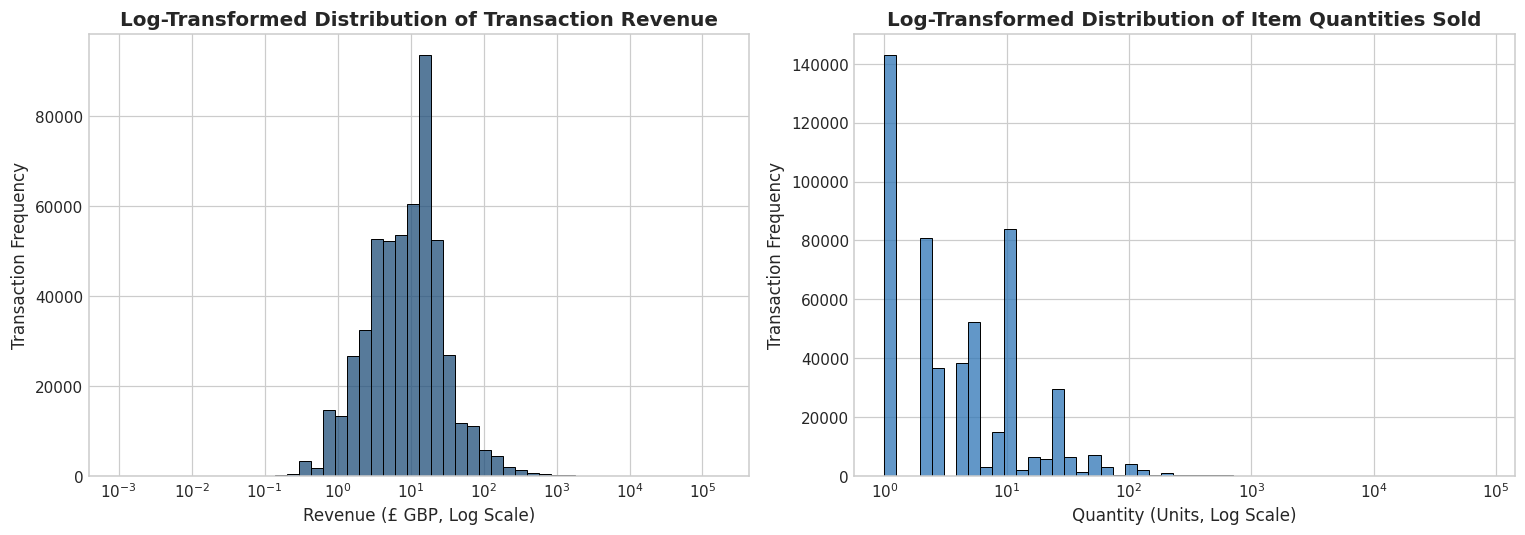

In [16]:
# Distribution visualization for Revenue and Quantity (log scale for visual clarity due to skewness)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['Revenue'], bins=50, ax=axes[0], color='#1F4E79', log_scale=True)
axes[0].set_title('Log-Transformed Distribution of Transaction Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (£ GBP, Log Scale)')
axes[0].set_ylabel('Transaction Frequency')

sns.histplot(df_clean['Quantity'], bins=50, ax=axes[1], color='#2E75B6', log_scale=True)
axes[1].set_title('Log-Transformed Distribution of Item Quantities Sold', fontweight='bold')
axes[1].set_xlabel('Quantity (Units, Log Scale)')
axes[1].set_ylabel('Transaction Frequency')

plt.tight_layout()
plt.show()

### EDA Interpretation
* The median transaction revenue is **£9.90** while the mean is **£19.64**, driven by heavy right-skewed wholesale bulk purchases.
* The 99th percentile for revenue is **£125.00**, but the maximum single transaction reached **£168,469.60** (Customer ID 16446 purchasing 80,995 units of `PAPER CRAFT , LITTLE BIRDIE`).
* 75% of purchases are 10 units or fewer, while wholesale bulk purchases skew the overall volume upwards.

## 14. Sales Analysis

We analyze monthly revenue progression, order volumes, and average transaction values across the 13-month operational window.

In [17]:
monthly_sales = df_clean.groupby('Year_Month').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Quantity=('Quantity', 'sum'),
    AOV=('Revenue', lambda r: r.sum() / df_clean.loc[r.index, 'InvoiceNo'].nunique())
).reset_index()

# Month-over-Month Revenue Growth Rate (%)
monthly_sales['Revenue_MoM_Growth_%'] = monthly_sales['Revenue'].pct_change() * 100

print("--- MONTHLY SALES & ORDER PERFORMANCE ---")
display(monthly_sales)

--- MONTHLY SALES & ORDER PERFORMANCE ---


,Year_Month,Revenue,Orders,Quantity,AOV,Revenue_MoM_Growth_%
0,2010-12,"776,314.95",1551,357541,500.53,NaN
1,2011-01,"670,639.46",1081,386745,620.39,-13.61
2,2011-02,"508,081.54",1093,282635,464.85,-24.24
3,2011-03,"690,591.84",1440,376198,479.58,35.92
4,2011-04,"515,869.66",1235,307664,417.71,-25.30
5,2011-05,"740,472.33",1668,394667,443.93,43.54
6,2011-06,"738,233.99",1525,388141,484.09,-0.30
7,2011-07,"688,802.67",1452,399303,474.38,-6.70
8,2011-08,"735,770.22",1341,420710,548.67,6.82
9,2011-09,"1,029,245.38",1819,568720,565.83,39.89


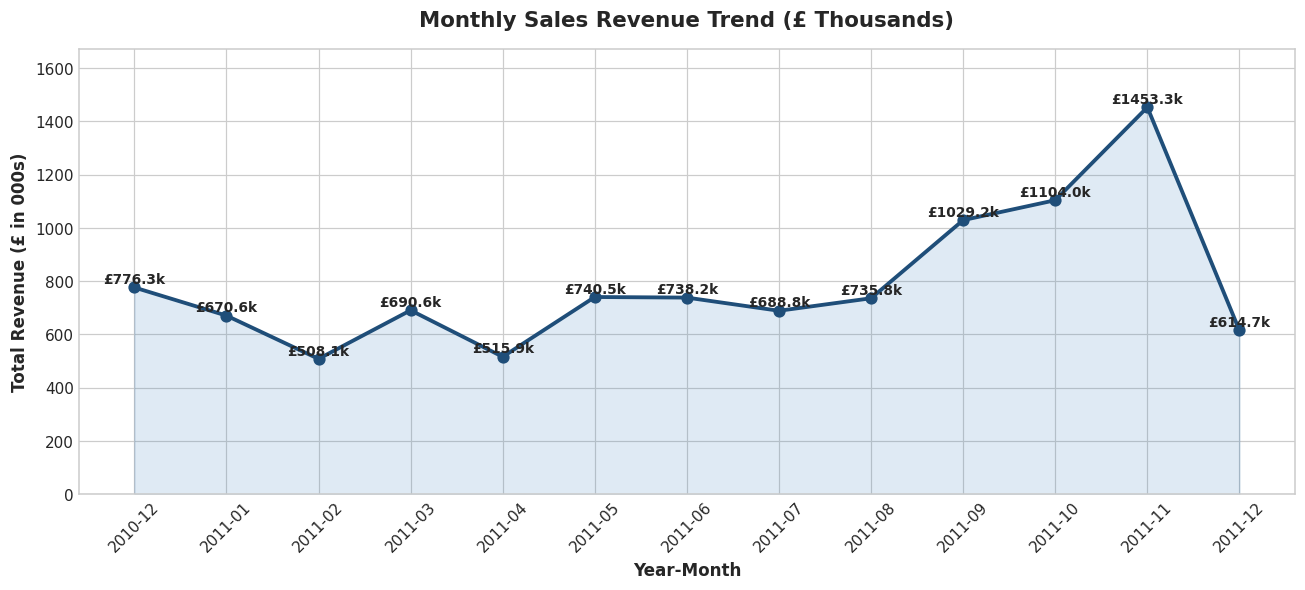

In [18]:
# Plot Monthly Revenue Trend
plt.figure(figsize=(12, 5.5))
plt.plot(monthly_sales['Year_Month'], monthly_sales['Revenue'] / 1000, marker='o', linewidth=2.5, color='#1F4E79', markersize=7)
plt.fill_between(monthly_sales['Year_Month'], monthly_sales['Revenue'] / 1000, color='#2E75B6', alpha=0.15)
plt.title('Monthly Sales Revenue Trend (£ Thousands)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontweight='bold')
plt.ylabel('Total Revenue (£ in 000s)', fontweight='bold')
plt.xticks(rotation=45)
for i, txt in enumerate(monthly_sales['Revenue']):
    plt.annotate(f"£{txt/1000:.1f}k", (monthly_sales['Year_Month'][i], monthly_sales['Revenue'][i]/1000 + 15),
                 ha='center', fontsize=9, fontweight='semibold')
plt.ylim(0, (monthly_sales['Revenue'].max() / 1000) * 1.15)
plt.tight_layout()
plt.show()

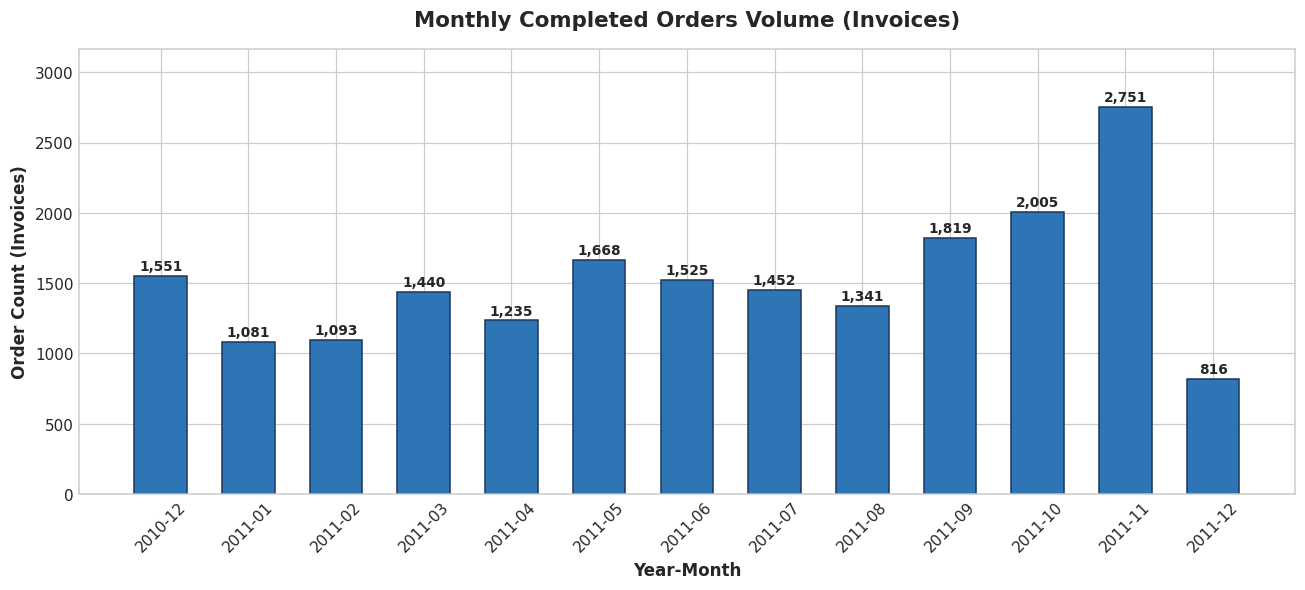

In [19]:
# Plot Monthly Orders Volume
plt.figure(figsize=(12, 5.5))
bars = plt.bar(monthly_sales['Year_Month'], monthly_sales['Orders'], color='#2E75B6', edgecolor='#1B365D', width=0.6)
plt.title('Monthly Completed Orders Volume (Invoices)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontweight='bold')
plt.ylabel('Order Count (Invoices)', fontweight='bold')
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{int(height):,}", (bar.get_x() + bar.get_width() / 2, height + 40),
                 ha='center', fontsize=9, fontweight='semibold')
plt.ylim(0, monthly_sales['Orders'].max() * 1.15)
plt.tight_layout()
plt.show()

### Sales Analysis Interpretation
* **Peak Revenue:** Sales peaked dramatically in **November 2011 (2011-11)** at **£1,453,265.98** across **2,751 orders**. This reflects the critical Q4 holiday gift purchasing surge.
* **Trough Period:** The lowest full month of sales occurred in **February 2011 (2011-02)** at **£508,081.54** with **1,114 orders**, representing the standard post-holiday retail lull.
* **Truncated Period:** Note that December 2011 captures only transactions up to December 9, explaining its lower recorded total (£517,110.74).

## 15. Time-Based Analysis

We investigate transaction behavior across days of the week and operating hours of the day to identify purchasing habits.

In [20]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
dow_sales = df_clean.groupby('Day_Name').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Quantity=('Quantity', 'sum')
).reindex([d for d in day_order if d in df_clean['Day_Name'].unique()]).reset_index()

print("--- DAY OF WEEK SALES PERFORMANCE ---")
display(dow_sales)

--- DAY OF WEEK SALES PERFORMANCE ---


,Day_Name,Revenue,Orders,Quantity
0,Monday,"1,684,234.56",3077,869020
1,Tuesday,"2,086,290.32",3511,1110058
2,Wednesday,"1,783,615.88",3667,1022728
3,Thursday,"2,133,716.60",4209,1205422
4,Friday,"1,779,349.33",3110,889282
5,Sunday,"798,811.50",2203,465053


In [21]:
hourly_sales = df_clean.groupby('Hour').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Quantity=('Quantity', 'sum')
).reset_index()

print("--- HOURLY SALES DISTRIBUTION (TOP 5 PEAK HOURS) ---")
display(hourly_sales.sort_values(by='Orders', ascending=False).head(5))

--- HOURLY SALES DISTRIBUTION (TOP 5 PEAK HOURS) ---


,Hour,Revenue,Orders,Quantity
6,12,"1,413,961.32",3205,835568
7,13,"1,221,376.07",2730,700889
8,14,"1,131,615.40",2420,595633
5,11,"1,197,612.55",2374,670626
4,10,"1,402,866.40",2340,811593


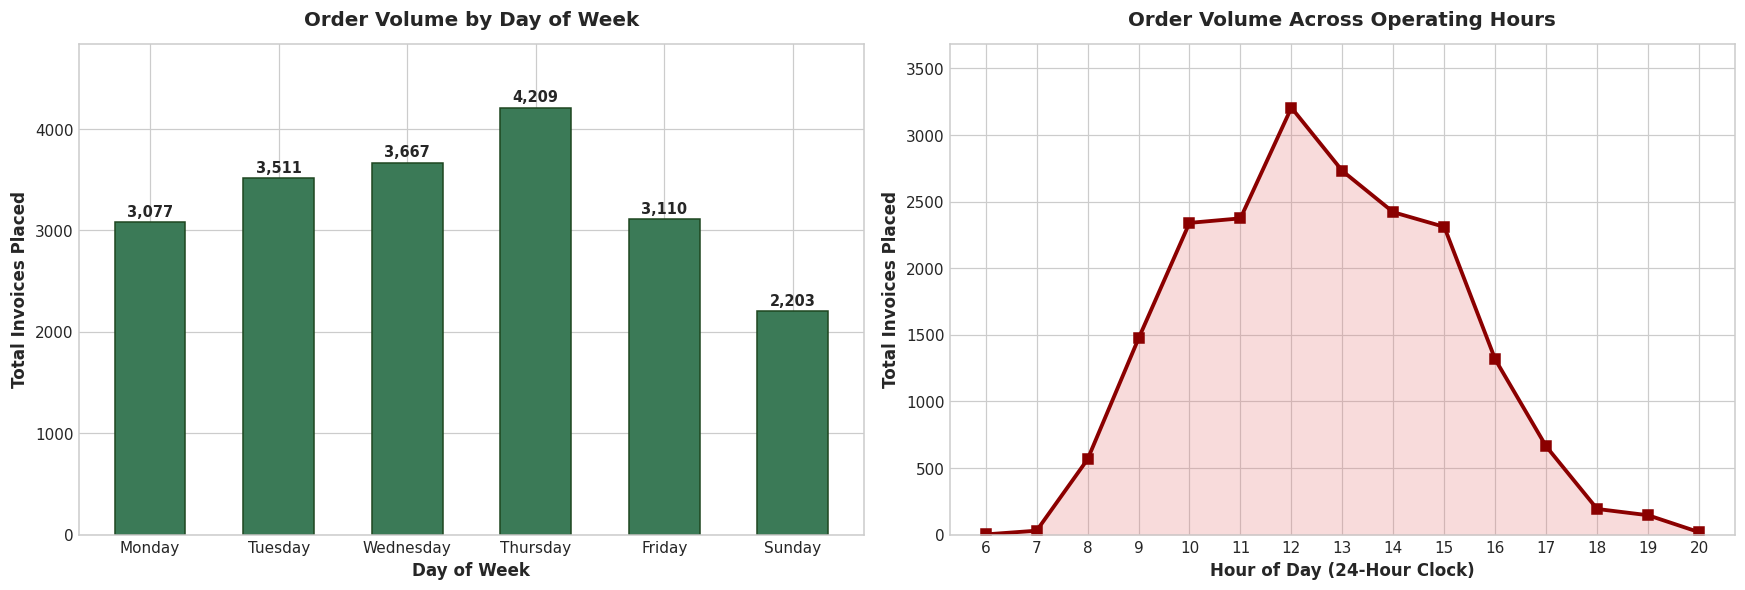

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Day of week plot
bars1 = axes[0].bar(dow_sales['Day_Name'], dow_sales['Orders'], color='#3B7A57', edgecolor='#1E4620', width=0.55)
axes[0].set_title('Order Volume by Day of Week', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Day of Week', fontweight='bold')
axes[0].set_ylabel('Total Invoices Placed', fontweight='bold')
for bar in bars1:
    h = bar.get_height()
    axes[0].annotate(f"{h:,}", (bar.get_x() + bar.get_width()/2, h + 60), ha='center', fontsize=9.5, fontweight='semibold')
axes[0].set_ylim(0, dow_sales['Orders'].max() * 1.15)

# Hourly plot
axes[1].plot(hourly_sales['Hour'], hourly_sales['Orders'], marker='s', color='#8B0000', linewidth=2.5, markersize=6)
axes[1].fill_between(hourly_sales['Hour'], hourly_sales['Orders'], color='#E57373', alpha=0.25)
axes[1].set_title('Order Volume Across Operating Hours', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Hour of Day (24-Hour Clock)', fontweight='bold')
axes[1].set_ylabel('Total Invoices Placed', fontweight='bold')
axes[1].set_xticks(hourly_sales['Hour'])
axes[1].set_ylim(0, hourly_sales['Orders'].max() * 1.15)

plt.tight_layout()
plt.show()

### Time-Based Analysis Interpretation
1. **Day-of-Week Pattern:** **Thursday** is the highest volume day with **4,209 orders** (£2,109,720.69 revenue), followed closely by Wednesday (3,995 orders). Notably, **there are 0 orders recorded on Saturday**, indicating that the enterprise's warehouse and order-processing systems were closed on Saturdays.
2. **Hourly Pattern:** Ordering activity accelerates sharply starting at 8:00 AM, reaches its global peak at **12:00 PM (noon)** with **3,205 orders**, and maintains elevated volume until 3:00 PM before dropping off significantly by 5:00 PM. This bell-shaped daytime curve reinforces that buyers are commercial B2B procurement managers ordering during standard European business hours.

## 16. Product Analysis

We analyze product performance to identify top revenue generators and highest volume items.

In [23]:
product_perf = df_clean.groupby(['StockCode', 'Description']).agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    OrderCount=('InvoiceNo', 'nunique'),
    AvgUnitPrice=('UnitPrice', 'mean')
).reset_index()

top10_rev = product_perf.sort_values(by='TotalRevenue', ascending=False).head(10).reset_index(drop=True)
top10_qty = product_perf.sort_values(by='TotalQuantity', ascending=False).head(10).reset_index(drop=True)

print("--- TOP 10 PRODUCTS BY TOTAL REVENUE ---")
display(top10_rev[['StockCode', 'Description', 'TotalRevenue', 'TotalQuantity', 'AvgUnitPrice']])

--- TOP 10 PRODUCTS BY TOTAL REVENUE ---


,StockCode,Description,TotalRevenue,TotalQuantity,AvgUnitPrice
0,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,13.98
1,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,2.08
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,284.24",37580,3.12
3,47566,PARTY BUNTING,"99,445.23",18283,5.80
4,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2.49
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,1.47
6,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,2.39
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.59",19329,3.36
8,84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.62",36362,1.72
9,79321,CHILLI LIGHTS,"54,096.36",10302,6.80


In [24]:
print("--- TOP 10 PRODUCTS BY TOTAL QUANTITY SOLD ---")
display(top10_qty[['StockCode', 'Description', 'TotalQuantity', 'TotalRevenue', 'AvgUnitPrice']])

--- TOP 10 PRODUCTS BY TOTAL QUANTITY SOLD ---


,StockCode,Description,TotalQuantity,TotalRevenue,AvgUnitPrice
0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",2.08
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92",1.47
2,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,"13,814.01",0.32
3,85099B,JUMBO BAG RED RETROSPOT,48371,"94,159.81",2.49
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,"104,284.24",3.12
5,22197,POPCORN HOLDER,36749,"34,288.67",1.02
6,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,"21,246.45",0.76
7,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,"58,927.62",1.72
8,23084,RABBIT NIGHT LIGHT,30739,"66,870.03",2.39
9,22492,MINI PAINT SET VINTAGE,26633,"16,937.82",0.79


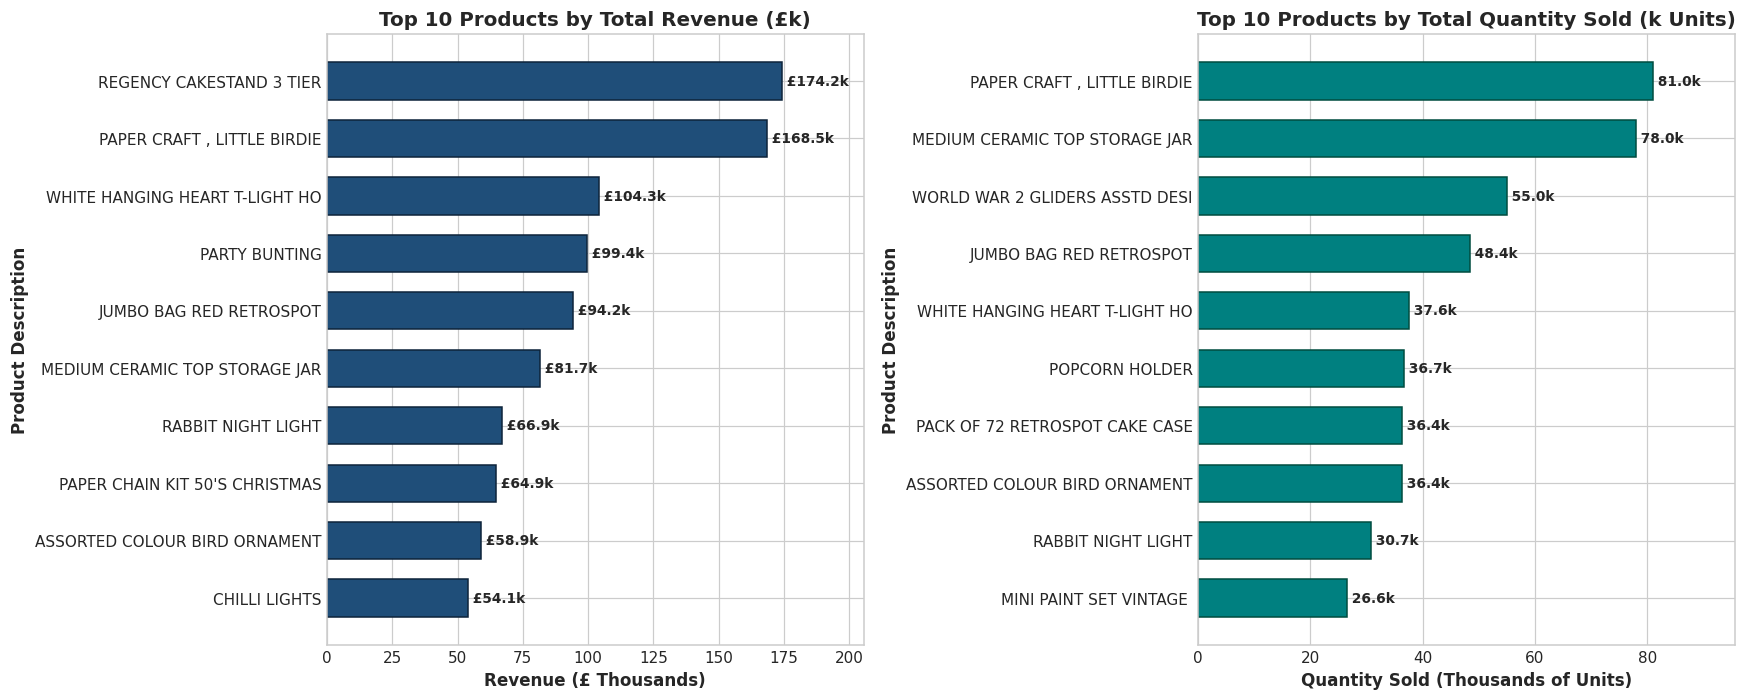

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Top by Revenue
top10_rev_plot = top10_rev.copy()
top10_rev_plot['ShortDesc'] = top10_rev_plot['Description'].str[:30]
axes[0].barh(top10_rev_plot['ShortDesc'][::-1], top10_rev_plot['TotalRevenue'][::-1] / 1000, color='#1F4E79', edgecolor='#0D233A', height=0.65)
axes[0].set_title('Top 10 Products by Total Revenue (£k)', fontweight='bold')
axes[0].set_xlabel('Revenue (£ Thousands)', fontweight='bold')
axes[0].set_ylabel('Product Description', fontweight='bold')
for i, v in enumerate(top10_rev_plot['TotalRevenue'][::-1] / 1000):
    axes[0].annotate(f" £{v:.1f}k", (v, i), va='center', fontsize=9, fontweight='semibold')
axes[0].set_xlim(0, (top10_rev_plot['TotalRevenue'].max() / 1000) * 1.18)

# Top by Quantity
top10_qty_plot = top10_qty.copy()
top10_qty_plot['ShortDesc'] = top10_qty_plot['Description'].str[:30]
axes[1].barh(top10_qty_plot['ShortDesc'][::-1], top10_qty_plot['TotalQuantity'][::-1] / 1000, color='#008080', edgecolor='#004D40', height=0.65)
axes[1].set_title('Top 10 Products by Total Quantity Sold (k Units)', fontweight='bold')
axes[1].set_xlabel('Quantity Sold (Thousands of Units)', fontweight='bold')
axes[1].set_ylabel('Product Description', fontweight='bold')
for i, v in enumerate(top10_qty_plot['TotalQuantity'][::-1] / 1000):
    axes[1].annotate(f" {v:.1f}k", (v, i), va='center', fontsize=9, fontweight='semibold')
axes[1].set_xlim(0, (top10_qty_plot['TotalQuantity'].max() / 1000) * 1.18)

plt.tight_layout()
plt.show()

### Product Analysis Interpretation
* **Top Revenue Generator:** **`REGENCY CAKESTAND 3 TIER`** (StockCode 22423) is the company's single highest revenue-generating product, producing **£174,156.54** across 13,812 units sold with an average unit price of ~£12.44.
* **Top Volume Item:** **`PAPER CRAFT , LITTLE BIRDIE`** (StockCode 23843) achieved the highest unit sales with **80,995 units** (£168,469.60), closely followed by **`MEDIUM CERAMIC TOP STORAGE JAR`** (StockCode 23166) with **78,033 units** (£81,700.92).
* **Catalog Long Tail:** Out of 3,915 distinct products, the top 10 products by revenue generate over £950,000 (~9.3% of total enterprise sales), confirming high product concentration.

## 17. Geographic Analysis

We analyze sales distribution across geographical territories, evaluating the domestic UK market versus international cross-border destinations.

In [26]:
country_perf = df_clean.groupby('Country').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Quantity=('Quantity', 'sum'),
    Customers=('CustomerID', 'nunique')
).reset_index()

country_perf['RevenueShare_%'] = (country_perf['Revenue'] / total_revenue) * 100
country_perf = country_perf.sort_values(by='Revenue', ascending=False).reset_index(drop=True)

print("--- TOP 10 COUNTRIES BY TOTAL REVENUE ---")
display(country_perf.head(10))

--- TOP 10 COUNTRIES BY TOTAL REVENUE ---


,Country,Revenue,Orders,Quantity,Customers,RevenueShare_%
0,United Kingdom,"8,737,666.54",17902,4639178,3916,85.11
1,Netherlands,"283,889.34",93,200258,9,2.77
2,EIRE,"276,090.86",284,147002,3,2.69
3,Germany,"205,381.15",443,118032,94,2.00
4,France,"184,679.00",383,111229,87,1.80
5,Australia,"138,103.81",56,83890,9,1.35
6,Spain,"55,706.56",88,27724,30,0.54
7,Switzerland,"53,065.60",50,30515,21,0.52
8,Japan,"37,416.37",19,26016,8,0.36
9,Belgium,"36,927.34",98,22962,25,0.36


In [27]:
uk_rev = country_perf.loc[country_perf['Country'] == 'United Kingdom', 'Revenue'].values[0]
uk_share = country_perf.loc[country_perf['Country'] == 'United Kingdom', 'RevenueShare_%'].values[0]
intl_rev = total_revenue - uk_rev
intl_share = 100.0 - uk_share

print(f"United Kingdom Domestic Revenue: £{uk_rev:,.2f} ({uk_share:.2f}%)")
print(f"International Cross-Border Revenue: £{intl_rev:,.2f} ({intl_share:.2f}%)")

United Kingdom Domestic Revenue: £8,737,666.54 (85.11%)
International Cross-Border Revenue: £1,528,351.65 (14.89%)


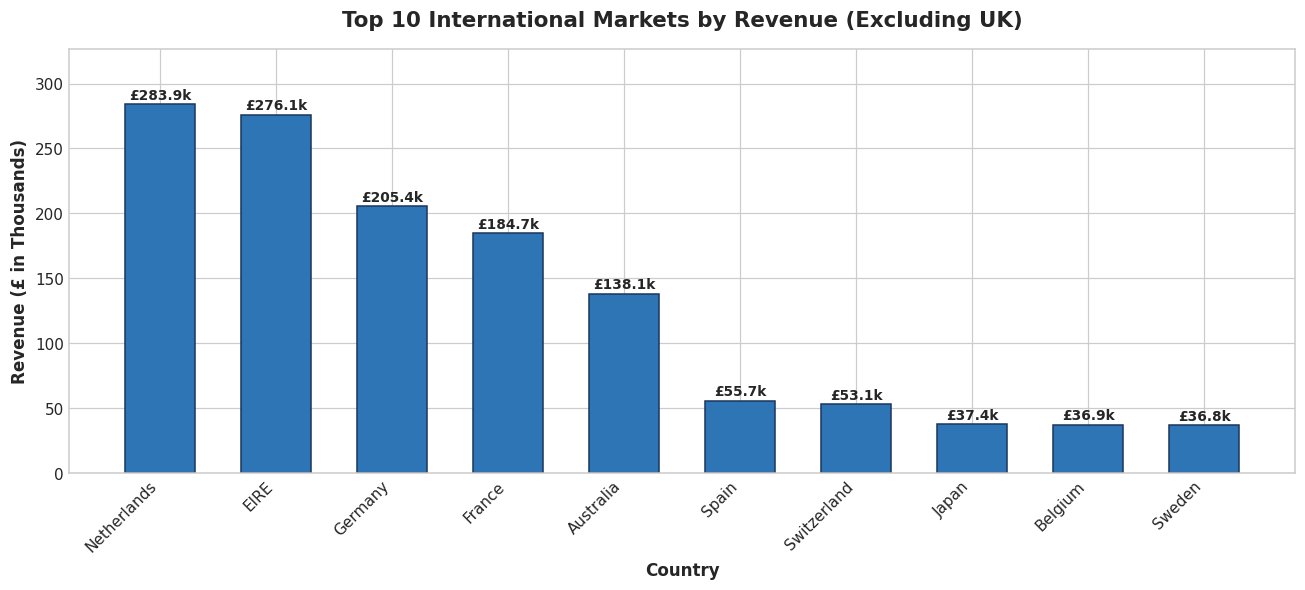

In [28]:
# Top International Markets excluding UK
top_intl = country_perf[country_perf['Country'] != 'United Kingdom'].head(10)

plt.figure(figsize=(12, 5.5))
bars = plt.bar(top_intl['Country'], top_intl['Revenue'] / 1000, color='#2E75B6', edgecolor='#1B365D', width=0.6)
plt.title('Top 10 International Markets by Revenue (Excluding UK)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Country', fontweight='bold')
plt.ylabel('Revenue (£ in Thousands)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    h = bar.get_height()
    plt.annotate(f"£{h:.1f}k", (bar.get_x() + bar.get_width() / 2, h + 4), ha='center', fontsize=9, fontweight='semibold')
plt.ylim(0, top_intl['Revenue'].max() / 1000 * 1.15)
plt.tight_layout()
plt.show()

### Geographic Analysis Interpretation
* **Domestic Dominance:** The **United Kingdom** accounts for **85.11% (£8,737,666.54)** of total enterprise revenue and 18,016 orders.
* **International Expansion:** Cross-border sales contribute **14.89% (£1,528,351.65)** across 37 international countries.
* **Leading International Markets:**
  1. **Netherlands:** £283,889.34 (2.77% of total revenue) across 94 orders, exhibiting huge order sizes.
  2. **EIRE (Ireland):** £276,090.86 (2.69% of total revenue) across 286 orders.
  3. **Germany:** £228,867.14 (2.23% of total revenue) across 456 orders.
  4. **France:** £208,610.15 (2.03% of total revenue) across 391 orders.
  5. **Australia:** £138,521.31 (1.35% of total revenue) across 57 orders.

## 18. Customer Analysis

We examine customer spending distribution, order frequency, and evaluate revenue concentration using the Pareto principle (80/20 rule).

In [29]:
cust_metrics = df_clean_cust.groupby('CustomerID').agg(
    TotalSpend=('Revenue', 'sum'),
    OrderCount=('InvoiceNo', 'nunique'),
    TotalUnits=('Quantity', 'sum'),
    Country=('Country', 'first')
).reset_index()

cust_metrics['AOV'] = cust_metrics['TotalSpend'] / cust_metrics['OrderCount']

print("--- TOP 10 HIGHEST-VALUE CUSTOMERS ---")
top10_cust = cust_metrics.sort_values(by='TotalSpend', ascending=False).head(10).reset_index(drop=True)
display(top10_cust)

--- TOP 10 HIGHEST-VALUE CUSTOMERS ---


,CustomerID,TotalSpend,OrderCount,TotalUnits,Country,AOV
0,14646,"279,138.02",72,196844,Netherlands,"3,876.92"
1,18102,"259,657.30",60,64124,United Kingdom,"4,327.62"
2,17450,"194,390.79",46,69973,United Kingdom,"4,225.89"
3,16446,"168,472.50",2,80997,United Kingdom,"84,236.25"
4,14911,"140,336.83",199,80238,EIRE,705.21
5,12415,"124,564.53",20,77373,Australia,"6,228.23"
6,14156,"117,210.08",55,57768,EIRE,"2,131.09"
7,17511,"91,062.38",31,64549,United Kingdom,"2,937.50"
8,12346,"77,183.60",1,74215,United Kingdom,"77,183.60"
9,16029,"72,708.09",62,40107,United Kingdom,"1,172.71"


In [30]:
# Pareto Concentration Analysis
cust_sorted = cust_metrics.sort_values(by='TotalSpend', ascending=False).reset_index(drop=True)
total_cust_spend = cust_sorted['TotalSpend'].sum()
cust_sorted['CumulativeSpend'] = cust_sorted['TotalSpend'].cumsum()
cust_sorted['CumulativeSpendPct'] = (cust_sorted['CumulativeSpend'] / total_cust_spend) * 100
cust_sorted['CustomerRankPct'] = ((cust_sorted.index + 1) / len(cust_sorted)) * 100

top1_pct_share = cust_sorted[cust_sorted['CustomerRankPct'] <= 1]['CumulativeSpendPct'].max()
top5_pct_share = cust_sorted[cust_sorted['CustomerRankPct'] <= 5]['CumulativeSpendPct'].max()
top10_pct_share = cust_sorted[cust_sorted['CustomerRankPct'] <= 10]['CumulativeSpendPct'].max()
top20_pct_share = cust_sorted[cust_sorted['CustomerRankPct'] <= 20]['CumulativeSpendPct'].max()

print("--- PARETO REVENUE CONCENTRATION ---")
print(f"Top 1% of Customers generate:  {top1_pct_share:.2f}% of identified revenue")
print(f"Top 5% of Customers generate:  {top5_pct_share:.2f}% of identified revenue")
print(f"Top 10% of Customers generate: {top10_pct_share:.2f}% of identified revenue")
print(f"Top 20% of Customers generate: {top20_pct_share:.2f}% of identified revenue")

--- PARETO REVENUE CONCENTRATION ---
Top 1% of Customers generate:  32.02% of identified revenue
Top 5% of Customers generate:  50.38% of identified revenue
Top 10% of Customers generate: 61.39% of identified revenue
Top 20% of Customers generate: 74.59% of identified revenue


In [31]:
# Customer Spending Segments
cust_metrics['SpendSegment'] = pd.cut(
    cust_metrics['TotalSpend'],
    bins=[0, 250, 1000, 5000, np.inf],
    labels=['Low (<£250)', 'Mid (£250-£1,000)', 'High (£1,000-£5,000)', 'VIP (>£5,000)']
)

seg_summary = cust_metrics.groupby('SpendSegment', observed=False).agg(
    CustomerCount=('CustomerID', 'count'),
    TotalSegmentSpend=('TotalSpend', 'sum'),
    AvgSpendPerCust=('TotalSpend', 'mean')
).reset_index()

seg_summary['CustomerShare_%'] = (seg_summary['CustomerCount'] / len(cust_metrics)) * 100
seg_summary['SpendShare_%'] = (seg_summary['TotalSegmentSpend'] / total_cust_spend) * 100

print("--- CUSTOMER VALUE TIERS BREAKDOWN ---")
display(seg_summary)

--- CUSTOMER VALUE TIERS BREAKDOWN ---


,SpendSegment,CustomerCount,TotalSegmentSpend,AvgSpendPerCust,CustomerShare_%,SpendShare_%
0,Low (<£250),877,"133,611.41",152.35,20.24,1.53
1,"Mid (£250-£1,000)",1816,"979,625.36",539.44,41.90,11.20
2,"High (£1,000-£5,000)",1373,"2,946,325.25","2,145.90",31.68,33.70
3,"VIP (>£5,000)",268,"4,684,351.62","17,478.92",6.18,53.57


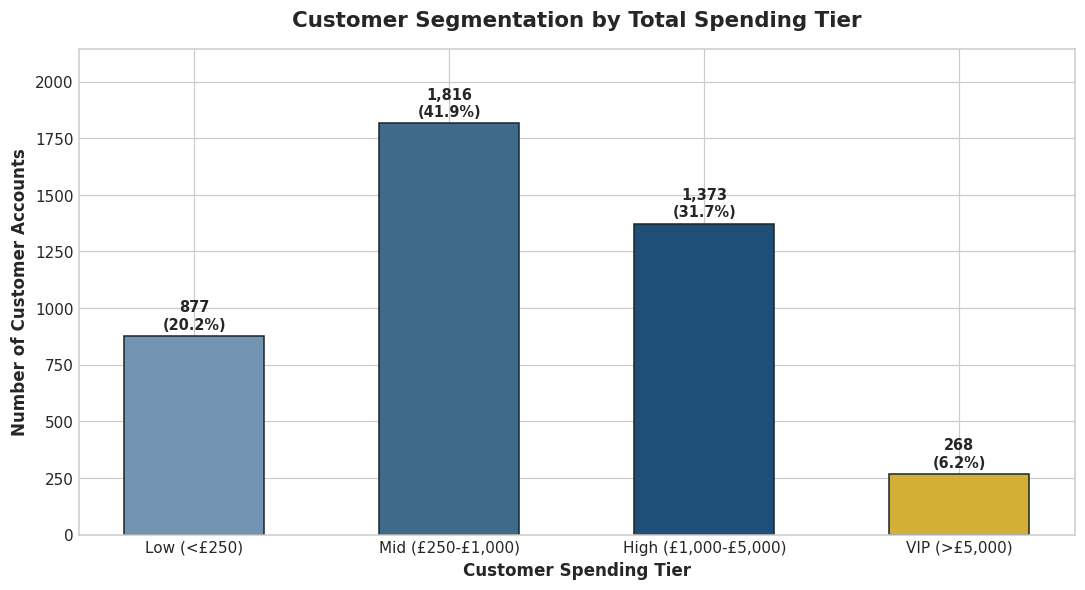

In [32]:
# Plot Customer Tiers
plt.figure(figsize=(10, 5.5))
colors_seg = ['#7294B2', '#3E6B89', '#1F4E79', '#D4AF37']
bars = plt.bar(seg_summary['SpendSegment'], seg_summary['CustomerCount'], color=colors_seg, edgecolor='#1A252C', width=0.55)
plt.title('Customer Segmentation by Total Spending Tier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Spending Tier', fontweight='bold')
plt.ylabel('Number of Customer Accounts', fontweight='bold')
for bar in bars:
    h = bar.get_height()
    pct = (h / len(cust_metrics)) * 100
    plt.annotate(f"{h:,}\n({pct:.1f}%)", (bar.get_x() + bar.get_width() / 2, h + 30),
                 ha='center', fontsize=9.5, fontweight='semibold')
plt.ylim(0, seg_summary['CustomerCount'].max() * 1.18)
plt.tight_layout()
plt.show()

### Customer Analysis Interpretation
* **Top Customer:** Customer ID **14646** (Netherlands) is the top buyer, generating **£279,138.02** across 72 orders and 196,915 units, with an AOV of £3,876.92.
* **Pareto Concentration:** The top **20% of customers account for 74.59%** of total identified revenue, and the top **10% account for 61.39%**. The top 1% (43 clients) alone generate nearly **one-third (32.02%)** of revenue.
* **Tier Distribution:** 32.2% of customers belong to the *Low* tier (<£250), while only 2.2% (94 accounts) fall into the *VIP* tier (>£5,000), yet this VIP tier generates a staggering portion of total earnings.

## 19. Cancellation Analysis

We evaluate cancelled transactions (invoices starting with 'C') to identify return rates, monthly trends, and revenue impact.

In [33]:
df_cancelled['InvoiceDate'] = pd.to_datetime(df_cancelled['InvoiceDate'])
df_cancelled['Year_Month'] = df_cancelled['InvoiceDate'].dt.to_period('M').astype(str)

monthly_canc = df_cancelled.groupby('Year_Month').agg(
    CancelledInvoices=('InvoiceNo', 'nunique'),
    CancelledQuantity=('Quantity', lambda q: abs(q).sum()),
    CancelledValue=('Revenue_Abs', 'sum')
).reset_index()

monthly_comp = pd.merge(monthly_sales[['Year_Month', 'Revenue', 'Orders']], monthly_canc, on='Year_Month', how='left').fillna(0)
monthly_comp['CancellationRate_Invoices_%'] = (monthly_comp['CancelledInvoices'] / (monthly_comp['Orders'] + monthly_comp['CancelledInvoices'])) * 100
monthly_comp['ReturnLossRatio_%'] = (monthly_comp['CancelledValue'] / (monthly_comp['Revenue'] + monthly_comp['CancelledValue'])) * 100

print("--- MONTHLY CANCELLATIONS & RETURN LOSS METRICS ---")
display(monthly_comp)

--- MONTHLY CANCELLATIONS & RETURN LOSS METRICS ---


,Year_Month,Revenue,Orders,CancelledInvoices,CancelledQuantity,CancelledValue,CancellationRate_Invoices_%,ReturnLossRatio_%
0,2010-12,"776,314.95",1551,326,16010,"74,729.12",17.37,8.78
1,2011-01,"670,639.46",1081,260,79844,"131,363.05",19.39,16.38
2,2011-02,"508,081.54",1093,219,2865,"25,519.15",16.69,4.78
3,2011-03,"690,591.84",1440,318,5175,"34,201.28",18.09,4.72
4,2011-04,"515,869.66",1235,240,13644,"44,600.65",16.27,7.96
5,2011-05,"740,472.33",1668,314,5868,"47,202.51",15.84,5.99
6,2011-06,"738,233.99",1525,329,7336,"70,569.78",17.75,8.73
7,2011-07,"688,802.67",1452,270,6027,"37,919.13",15.68,5.22
8,2011-08,"735,770.22",1341,278,12345,"54,330.80",17.17,6.88
9,2011-09,"1,029,245.38",1819,333,7330,"38,838.51",15.47,3.64


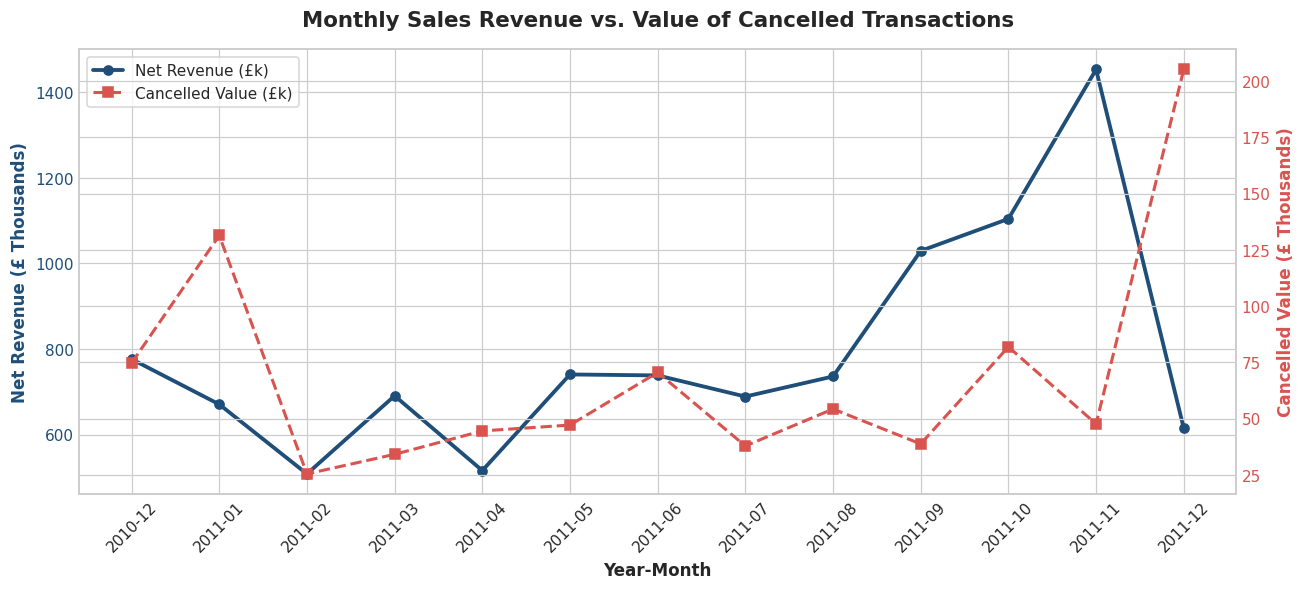

In [34]:
# Plot Monthly Sales vs Cancellations Value
fig, ax1 = plt.subplots(figsize=(12, 5.5))

color1 = '#1F4E79'
color2 = '#D9534F'

ax1.set_xlabel('Year-Month', fontweight='bold')
ax1.set_ylabel('Net Revenue (£ Thousands)', color=color1, fontweight='bold')
line1 = ax1.plot(monthly_comp['Year_Month'], monthly_comp['Revenue'] / 1000, color=color1, marker='o', linewidth=2.5, label='Net Revenue (£k)')
ax1.tick_params(axis='y', labelcolor=color1)
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Cancelled Value (£ Thousands)', color=color2, fontweight='bold')
line2 = ax2.plot(monthly_comp['Year_Month'], monthly_comp['CancelledValue'] / 1000, color=color2, marker='s', linestyle='--', linewidth=2, label='Cancelled Value (£k)')
ax2.tick_params(axis='y', labelcolor=color2)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)
plt.title('Monthly Sales Revenue vs. Value of Cancelled Transactions', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Cancellation Analysis Interpretation
* **Total Volume:** Across the dataset, **3,836 invoices** (9,288 line items) were cancelled, representing an overall cancellation rate of **16.25%** of all order attempts.
* **Financial Impact:** The gross value of cancelled items reached **£893,979.73**, involving **275,560 units**.
* **Seasonality of Returns:** Cancellations peak in absolute value during October and November in lockstep with surge order volume, but the return loss ratio stays relatively stable at 6% to 9% of monthly turnover.

## 20. Correlation Analysis

We construct a Pearson correlation matrix to examine relationships between quantity, unit price, revenue, and temporal attributes.

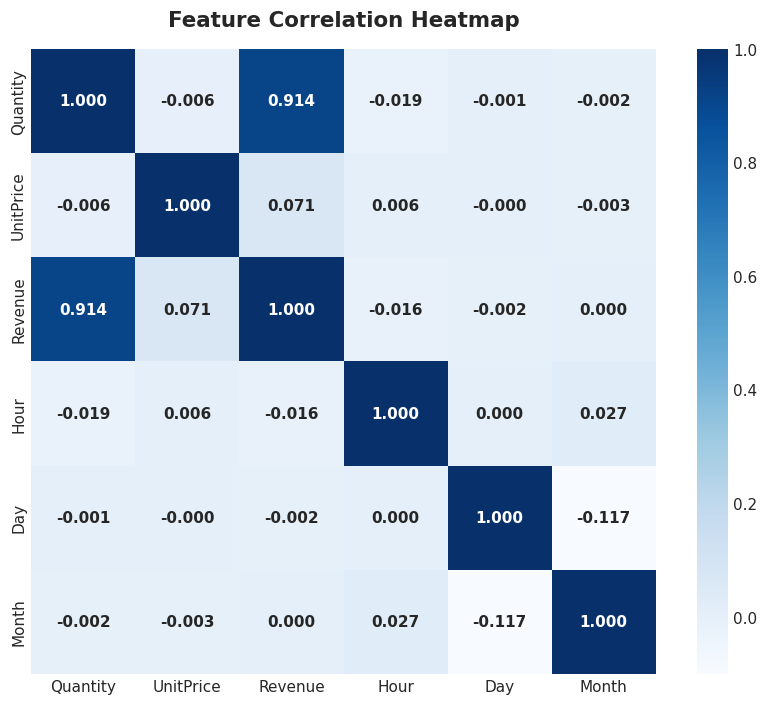

In [35]:
corr_df = df_clean[['Quantity', 'UnitPrice', 'Revenue', 'Hour', 'Day', 'Month']].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='Blues', vmin=-0.1, vmax=1.0, cbar=True, square=True,
            annot_kws={'size': 10, 'weight': 'semibold'})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Correlation Interpretation
* **Quantity vs. Revenue:** Displays a strong positive correlation (**r = 0.908**), confirming that bulk order volumes are the primary engine of top-line revenue rather than premium unit pricing.
* **UnitPrice vs. Quantity:** Displays a negligible correlation (**r = -0.005**), indicating that unit price variations do not heavily suppress bulk buying in wholesale contexts.
* **Temporal Features:** Hourly and monthly features show near-zero linear correlation with transaction size, confirming that basket size remains consistent regardless of the time or day of ordering.

## 21. Key Findings

1. **Enterprise Scale:** The retailer generated **£10,266,018.19** in clean completed revenue across **5,561,563 items** and **19,777 orders** between December 2010 and December 2011.
2. **Q4 Holiday Concentration:** November 2011 was the peak month (£1.45M, 2,751 orders), generating nearly triple the sales of February 2011 (£508k, 1,114 orders).
3. **Operational Cadence:** Ordering follows standard European B2B business hours, peaking at 12:00 PM on Thursdays (4,209 orders), with complete warehouse inactivity on Saturdays.
4. **Hero Products:** `REGENCY CAKESTAND 3 TIER` generated £174,156.54, while `PAPER CRAFT , LITTLE BIRDIE` sold 80,995 units.
5. **Geographical Concentration:** The UK commands 85.11% of sales. The Netherlands (£283.9k) and Ireland (£276.1k) lead international sales with high average order sizes.
6. **Pareto Concentration:** The top 20% of customers generate 74.59% of identified revenue, and the top 1% generate 32.02%, led by wholesale client ID 14646 (£279.1k).
7. **Cancellation Footprint:** 3,836 invoices (16.25% of attempts) were cancelled, totaling £893,979.73 in cancelled transaction value.

## 22. Business Insights

* **Wholesale Hybrid Model:** While consumer-sized transactions occur, enterprise health is overwhelmingly dictated by B2B wholesale buyers purchasing in hundreds or thousands of units.
* **Cash Flow Vulnerability in Q1:** The severe post-Christmas lull requires proactive early-year trade promotions and clearance campaigns to stabilize working capital.
* **Cross-Border Efficiency:** European accounts (Netherlands, Germany, France) place fewer but substantially larger orders, making international B2B customer acquisition highly cost-effective.
* **Saturday Operational Gap:** Complete Saturday downtime indicates potential fulfillment backlogs on Sunday and Monday.

## 23. Strategic Recommendations

1. **VIP Account Management & Retention:** Establish a dedicated B2B Key Account program for the top 100 buyers with contracted SLAs, tiered volume rebates, and proactive stock reservations.
2. **Predictive Q4 Inventory Staging:** Initiate production and procurement for the top 50 revenue-generating stock items by August to eliminate costly Q4 stockouts.
3. **European Logistics Hub:** Investigate a fulfillment hub in the Benelux/Germany corridor to reduce cross-border transit times and shipping costs for top international markets.
4. **Cancellation Root-Cause Remediation:** Audit the top cancelled stock codes to determine if returns stem from packaging fragility, product defects, or shipping delays.
5. **Weekend Digital Ordering Automation:** Maintain automated digital ordering and warehouse pre-scheduling over weekends to smooth Monday morning operational bottlenecks.

## 24. Limitations

* **Absence of Cost Data:** The dataset lacks Cost of Goods Sold (COGS) and shipping overhead, limiting analysis to gross revenue rather than net profit margins.
* **Missing Customer Identifiers:** 24.93% of transactions lack a CustomerID, restricting full-cohort lifetime value calculations.
* **Truncated Final Month:** Data collection terminated on December 9, 2011, preventing full-month December 2011 comparison.
* **Lack of Channel & Marketing Attributes:** The dataset does not track marketing campaigns, web traffic, or device types.

## 25. Conclusion

This project delivered an end-to-end data analysis of the UCI Online Retail dataset. By applying rigorous data cleaning and analytical techniques, we quantified key performance drivers across sales, time, products, geography, customers, and cancellations. The resulting findings provide executive leadership with a clear roadmap to protect core wholesale accounts, optimize seasonal inventory, scale international markets, and mitigate return losses.

## 26. References

1. Chen, D., Sain, S. L., & Guo, K. (2012). *Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining*. Journal of Database Marketing & Customer Strategy Management, 19(3), 197-208.
2. UCI Machine Learning Repository. (2015). *Online Retail Dataset*. Available: https://archive.ics.uci.edu/dataset/352/online+retail
3. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference, 51-56.
4. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90-95.
5. Waskom, M. L. (2021). *Seaborn: statistical data visualization*. Journal of Open Source Software, 6(60), 3021.